In [64]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score  

In [4]:
# Allowing the python to read the source of the data

data = ("D:\Oladimeji\Data Science\Project\Case Study 3.csv")
df = pd.read_csv(data)

In [5]:
# Checking the first 5 rolls of the DataFrame

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [6]:
# Making the row index 0 to be the columns name

df.columns = df.iloc[0]

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [7]:
# Dropping all the rows in index 0 to start the data from index 1

df = df.iloc[1: ].reset_index(drop=True)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
# To check the number of rows and columns that is in the DataFrame

df.shape

(30000, 25)

In [9]:
# Checking the information the data contains

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  object
 3   EDUCATION                   30000 non-null  object
 4   MARRIAGE                    30000 non-null  object
 5   AGE                         30000 non-null  object
 6   PAY_0                       30000 non-null  object
 7   PAY_2                       30000 non-null  object
 8   PAY_3                       30000 non-null  object
 9   PAY_4                       30000 non-null  object
 10  PAY_5                       30000 non-null  object
 11  PAY_6                       30000 non-null  object
 12  BILL_AMT1                   30000 non-null  object
 13  BILL_AMT2                   30000 non-null  ob

In [10]:
# To check the anomalies in the column SEX

df["SEX"].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [11]:
# To check the anomalies in the column EDUCATION

df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [12]:
# Replacing 0, 5, 6 with 4 in the EDUCATION column

df["EDUCATION"] = df["EDUCATION"].replace(["0","5","6"], "4")

In [13]:
# To confirm the replacement in the column EDUCATION

df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [14]:
# To check the anomalies in the column MARRIAGE

df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [15]:
# Replacing 0 with 3 and confirming the replacement in the column MARRIAGE

df["MARRIAGE"] = df["MARRIAGE"].replace("0","3")

df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

In [16]:
# Removing the ID because it does not have effect on the analysis

df.drop("ID", axis = 1, inplace = True)

In [17]:
# Cofirming the drop

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [18]:
# Renaming column "default payment next month" to "DEFAULT" for better usage

df.rename(columns ={"default payment next month":"DEFAULT"}, inplace=True)

In [19]:
# Given a single name to the columns heading to change the data type

int_col = df.columns

int_col

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object', name=0)

In [20]:
# Changing the data type from object to integer

df[int_col] = df[int_col].astype("int")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [22]:
# Getting the statistical information of the Data

df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


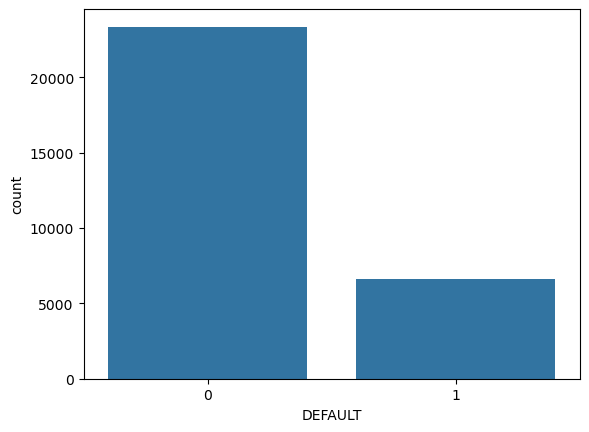

In [23]:
# Checking for the imbalance of the target column

sns.countplot(x="DEFAULT", data=df)
plt.show()

The countplot show that the target column is imbalance having a non defult of over 20,000 and default of less than 10,000

In [24]:
X = df.drop("DEFAULT", axis = 1)

X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [25]:
# Categorising all other columns except target column into X

cat_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [26]:
# Categorising the target column

y = df["DEFAULT"]

In [27]:
le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [28]:
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,2,1,1,0,3,4,4,1,1,0,0,2710,2306,846,377,384,414,0,494,0,0,0,0
1,12,1,1,1,5,1,4,2,2,2,3,2064,1547,2053,2344,2452,2402,0,699,885,946,0,1797
2,9,1,1,1,13,2,2,2,2,2,2,10068,6073,5886,6135,6365,6480,1211,1185,885,946,949,3576
3,5,1,1,0,16,2,2,2,2,2,2,12731,12968,13353,10118,10391,10482,1674,1674,1079,1043,1018,928
4,5,0,1,0,36,1,2,1,2,2,2,4628,3418,11227,8476,7794,7708,1674,7301,5346,4841,647,630


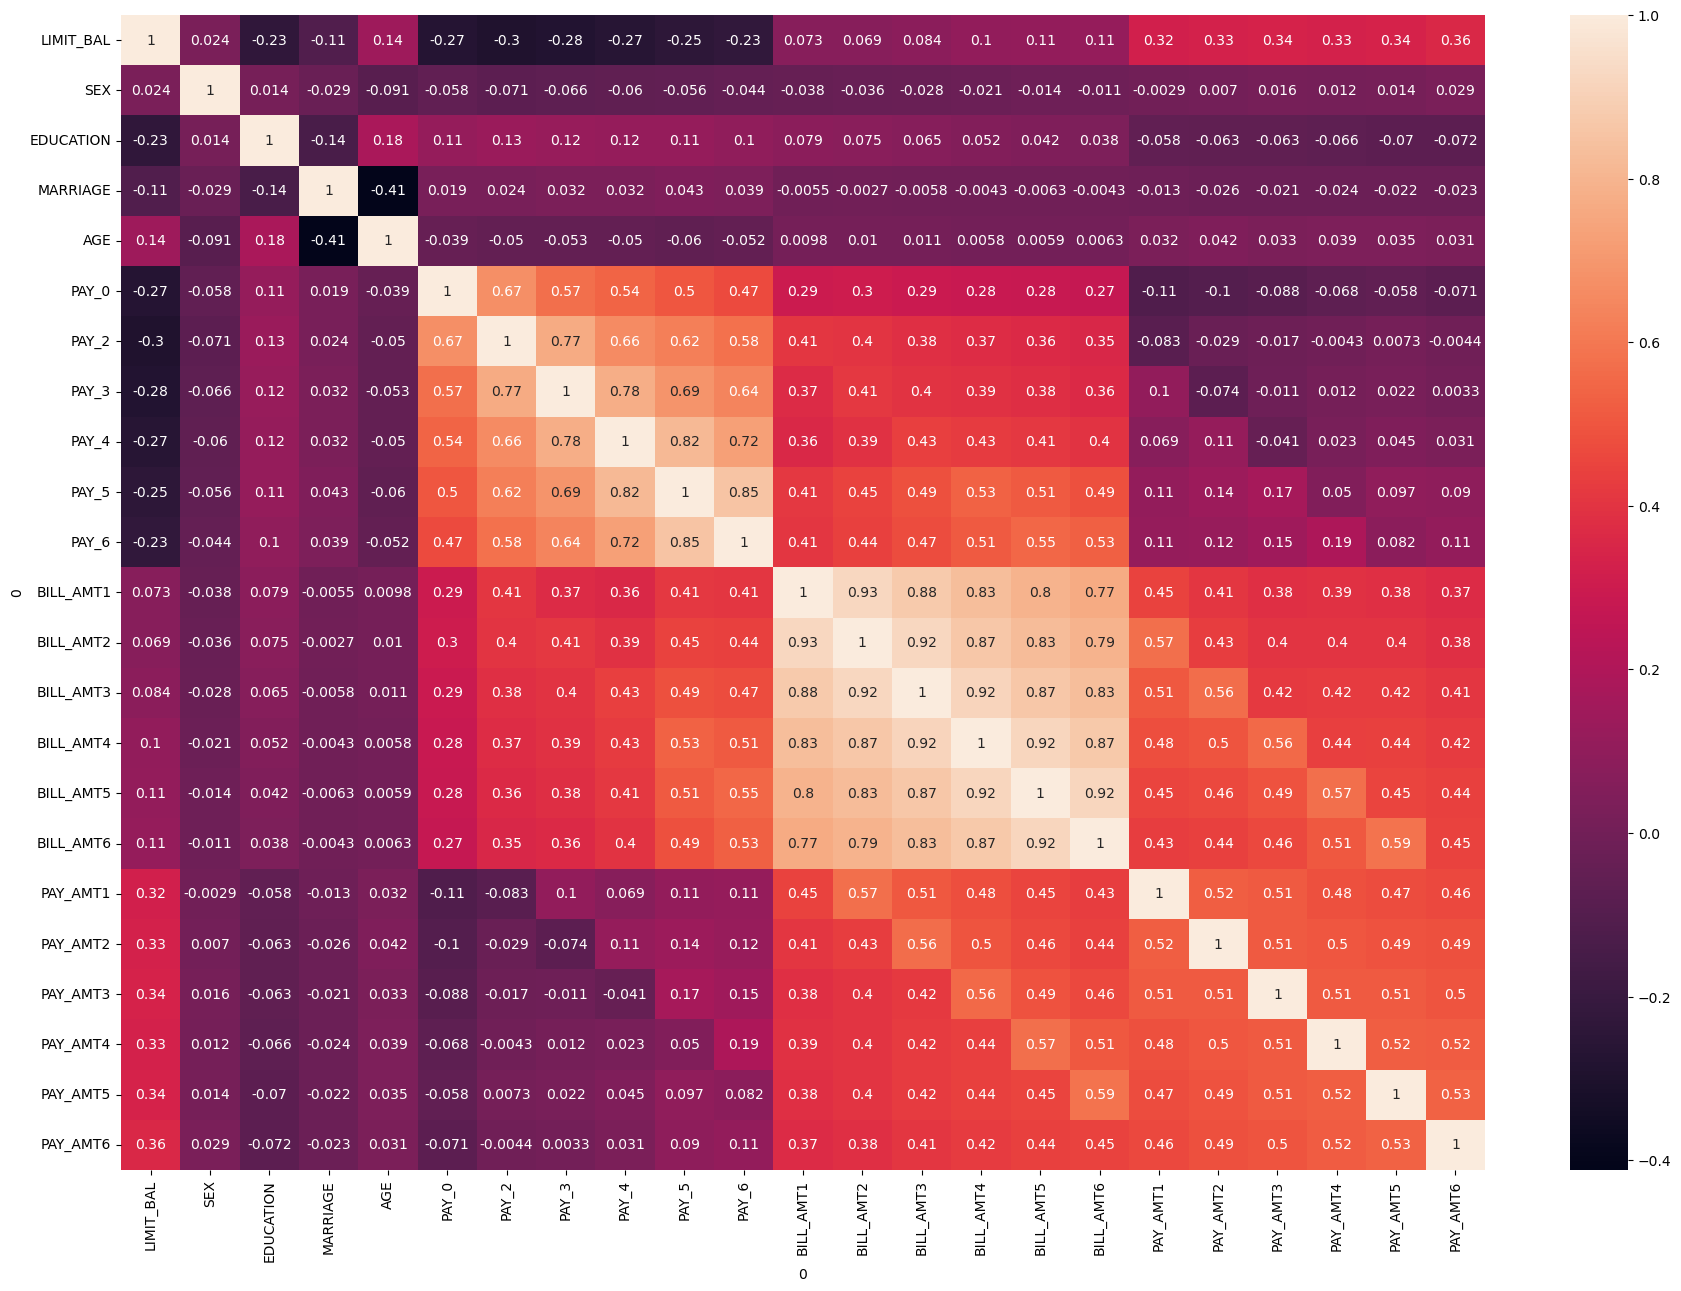

In [29]:
# Checking how correlated the fetures are

plt.figure(figsize=(22, 15))
sns.heatmap(X.corr(), annot=True)
plt.show()

In [30]:
scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [31]:
scaledX

array([[-1.1218921 ,  0.81016074,  0.21186989, ..., -1.0320808 ,
        -1.03291125, -1.01151476],
       [-0.36710385,  0.81016074,  0.21186989, ..., -0.52762649,
        -1.03291125, -0.05319092],
       [-0.59354032,  0.81016074,  0.21186989, ..., -0.52762649,
        -0.52427286,  0.89553369],
       ...,
       [-1.04641327, -1.23432296,  0.21186989, ...,  0.70044781,
        -0.0708397 ,  0.36544248],
       [-0.66901915, -1.23432296,  1.55508562, ..., -0.0876954 ,
         2.47878391, -0.13798418],
       [-0.89545562, -1.23432296,  0.21186989, ..., -0.52762649,
        -0.52427286, -0.51662076]], shape=(30000, 23))

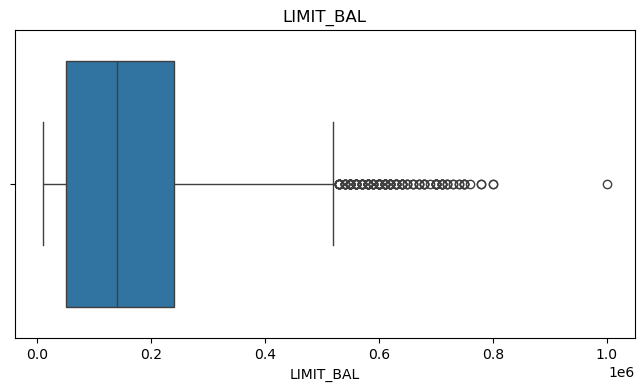

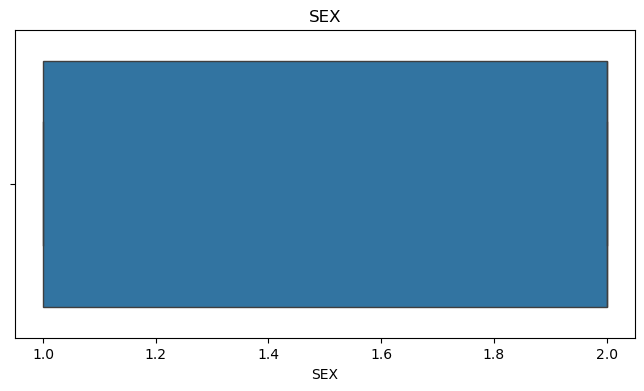

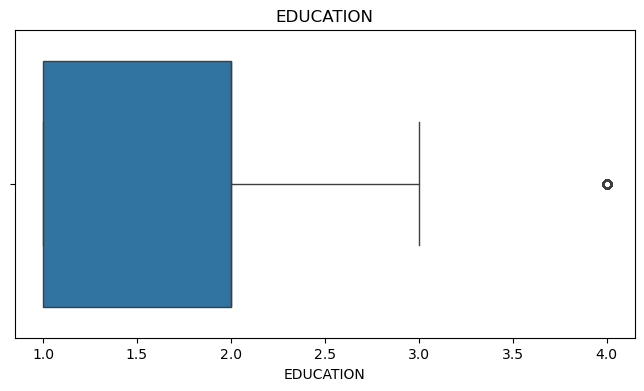

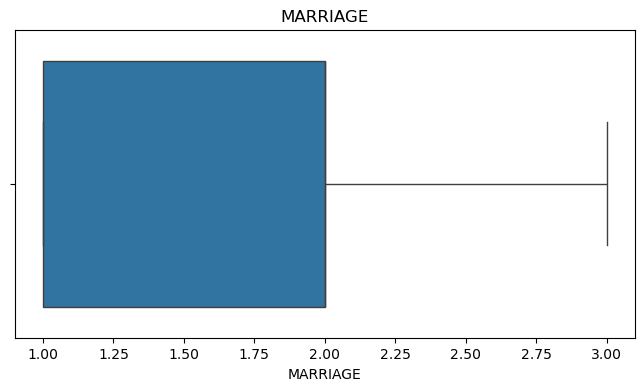

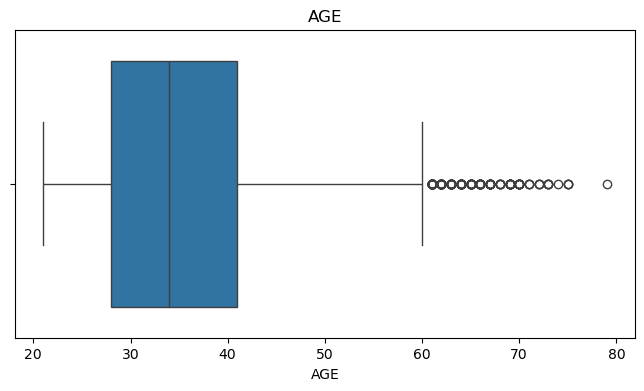

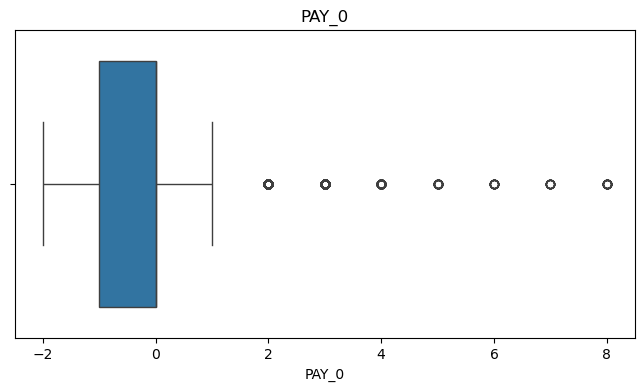

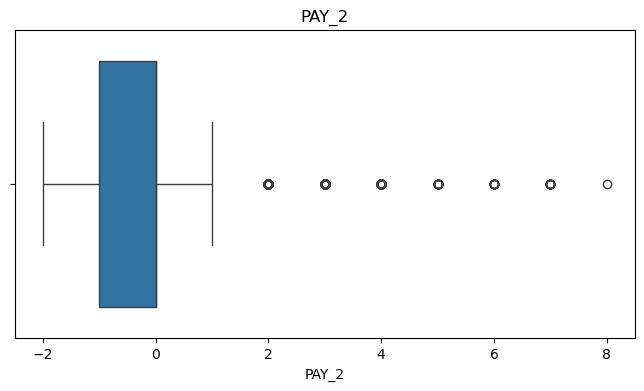

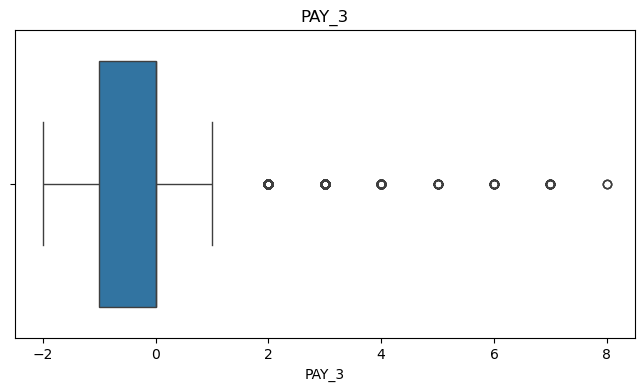

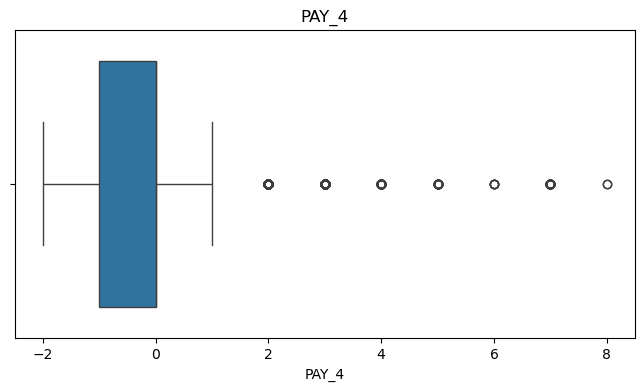

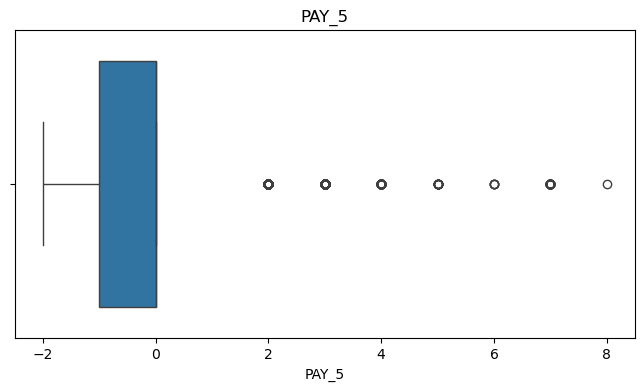

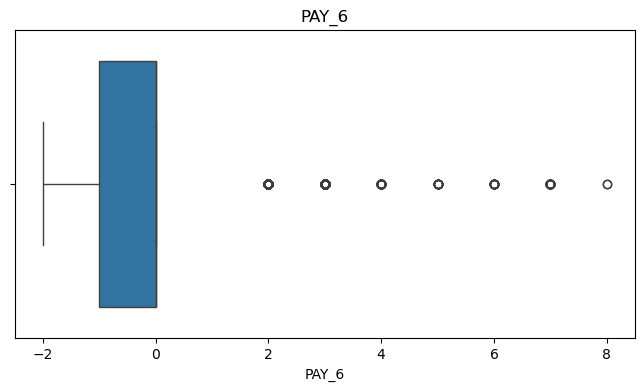

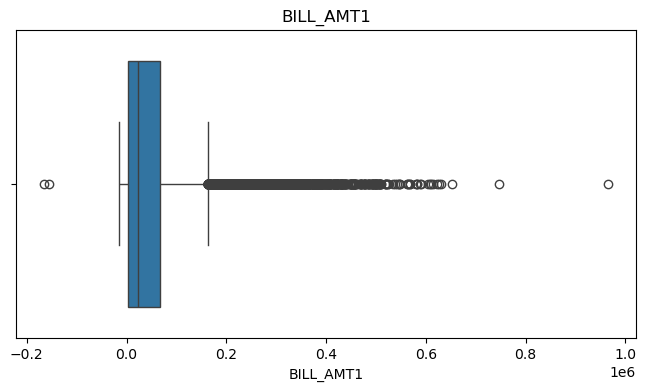

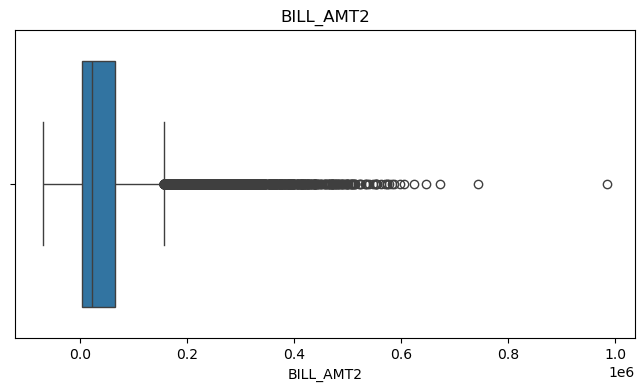

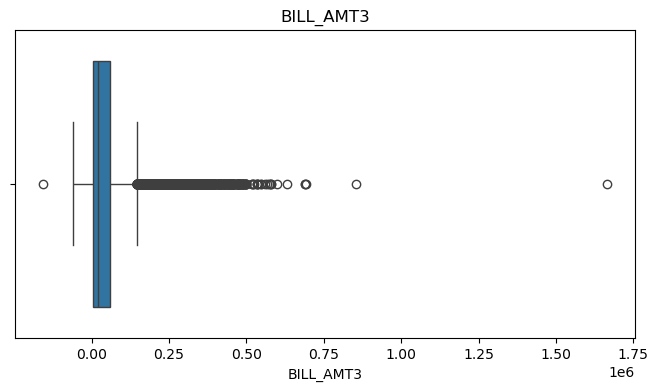

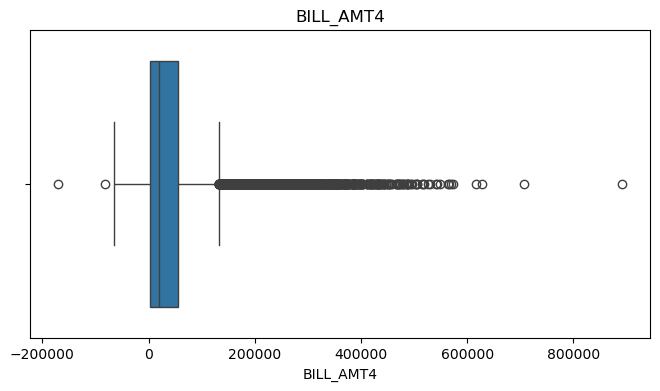

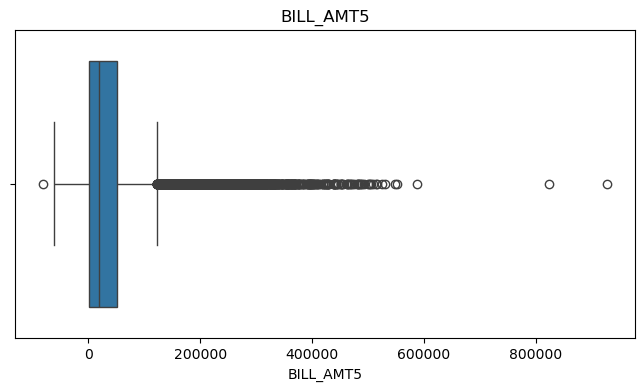

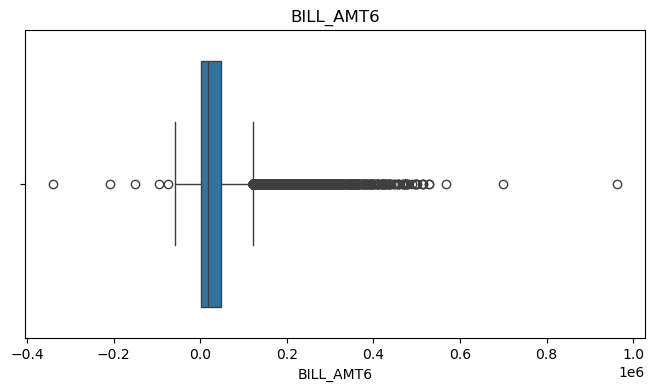

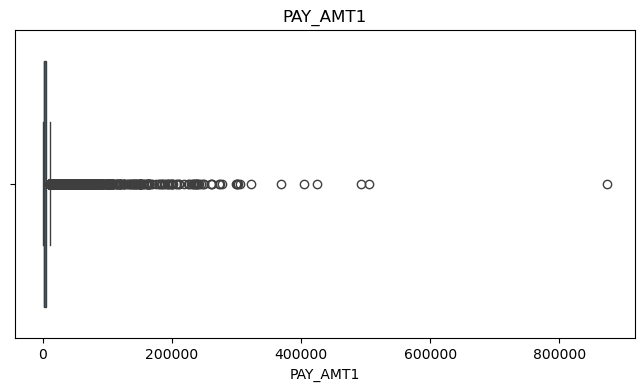

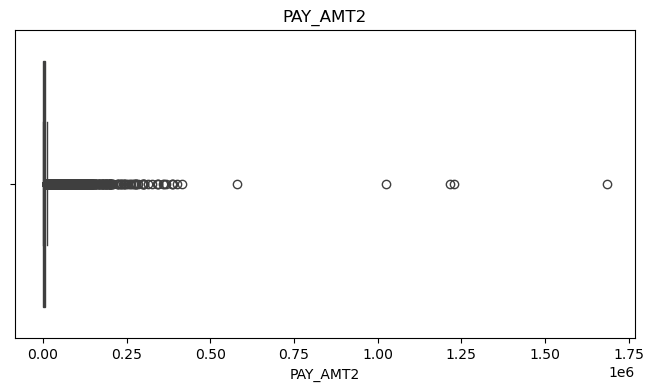

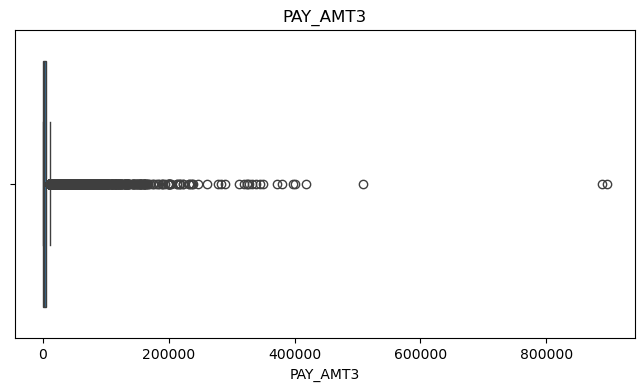

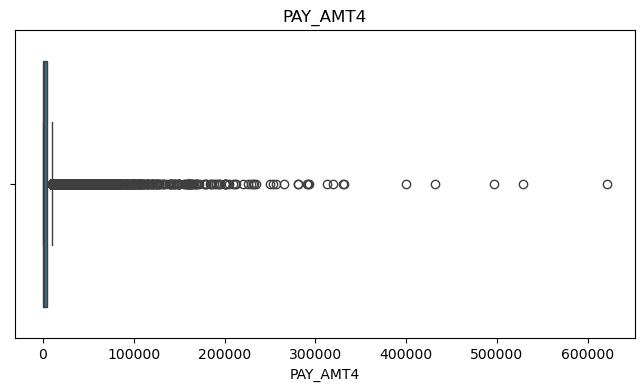

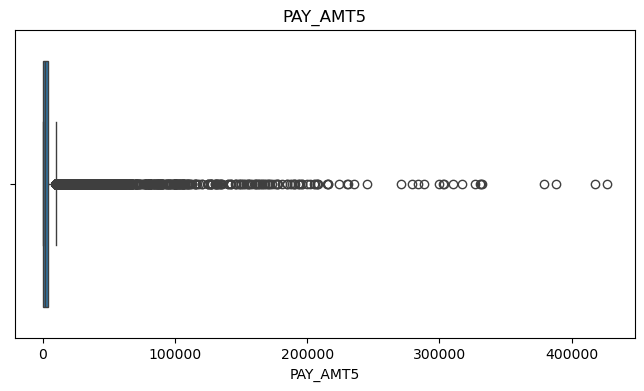

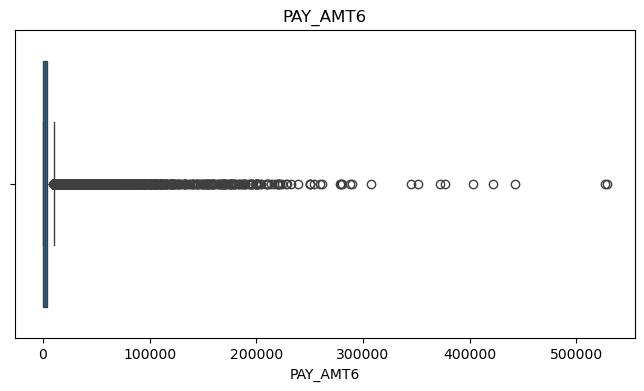

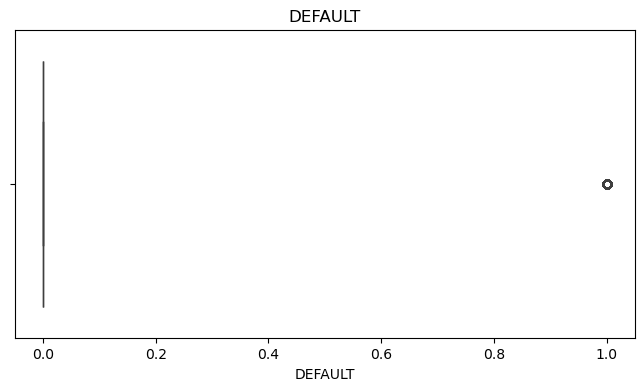

In [32]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

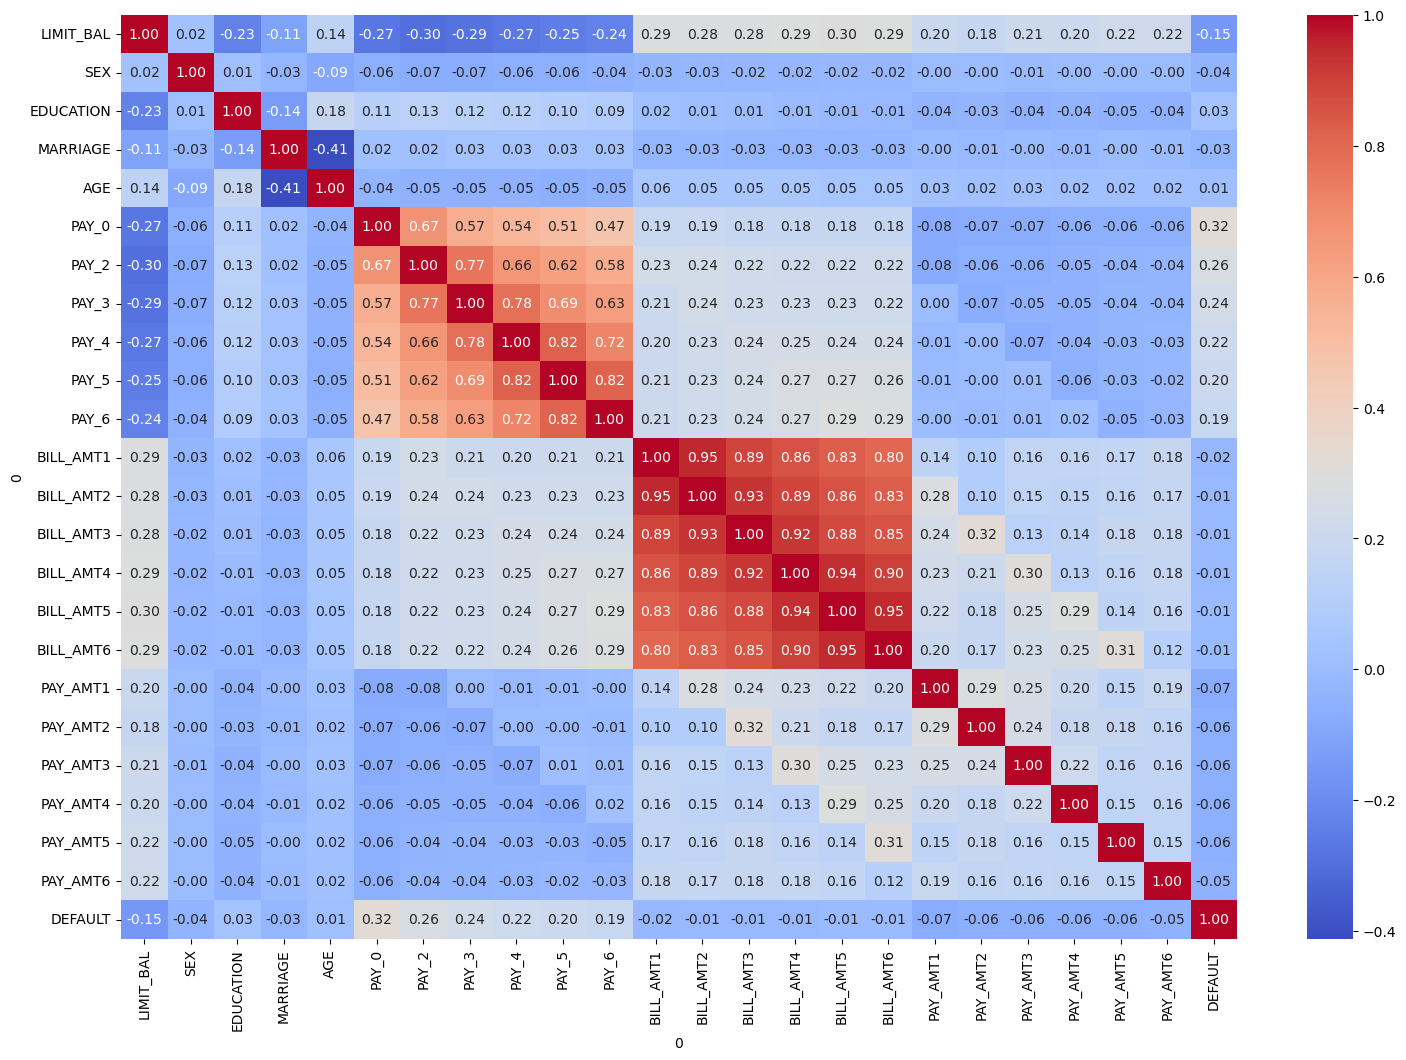

In [33]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

#### Relationship between each Features and DEFAULT

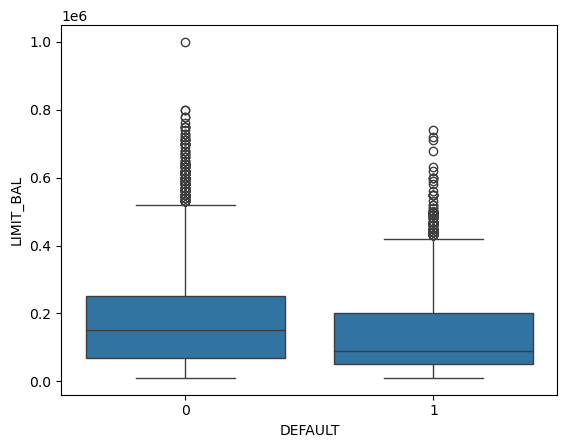

In [34]:
# Limit Balance
sns.boxplot(x="DEFAULT", y="LIMIT_BAL", data=df)
plt.show()
# Interpretation: Compare credit limits between defaulters and non-defaulters.

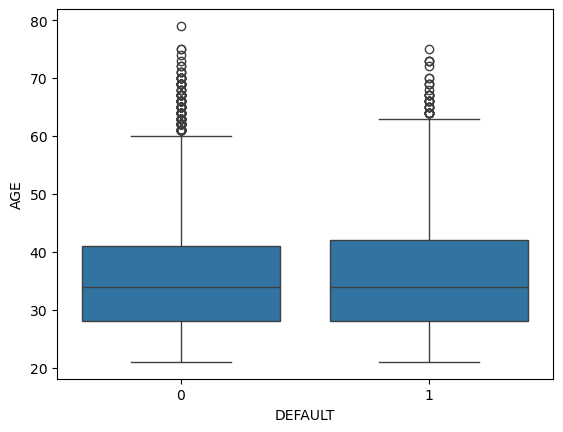

In [35]:
# Age
sns.boxplot(x="DEFAULT", y="AGE", data=df)
plt.show()
# Interpretation: Determine whether age influences default.

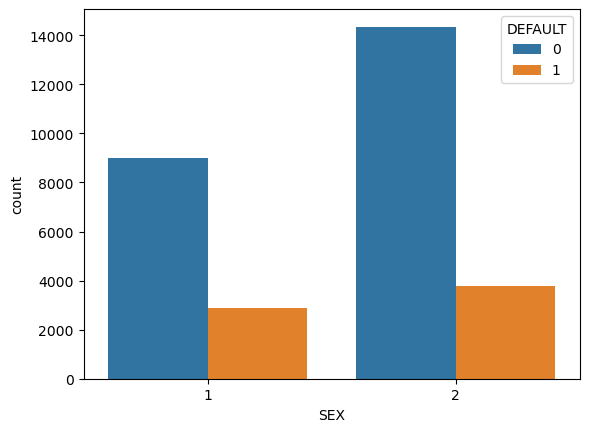

In [36]:
# Sex
sns.countplot(x="SEX", hue="DEFAULT", data=df)
plt.show()
# Interpretation: Compare default rates by gender.

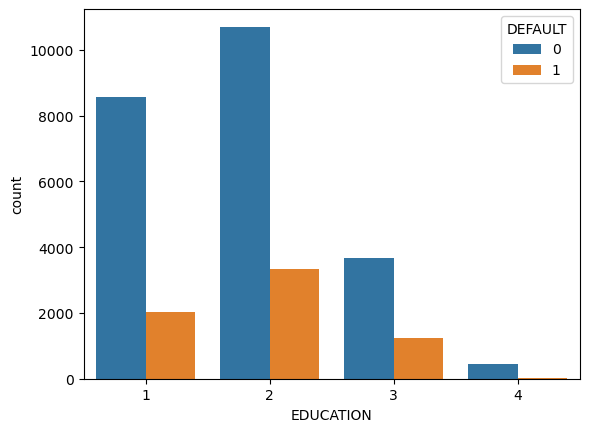

In [37]:
# Education
sns.countplot(x="EDUCATION", hue="DEFAULT", data=df)
plt.show()
# Interpretation: See whether education level is associated with default.

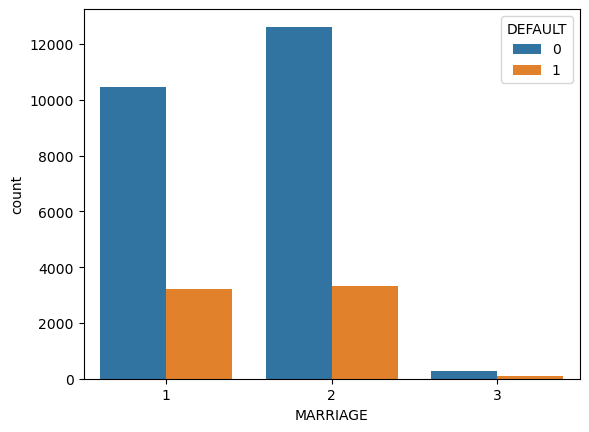

In [38]:
# Marriage
sns.countplot(x="MARRIAGE", hue="DEFAULT", data=df)
plt.show()
# Interpretation: Determine whether marital status influences repayment.

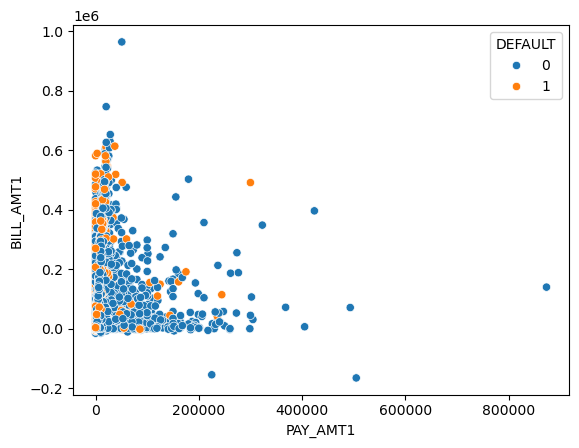

In [39]:
sns.scatterplot(
    x="PAY_AMT1",
    y="BILL_AMT1",
    hue="DEFAULT",
    data=df
)

plt.show()
# Interpretation: Compare bill amounts with repayments.

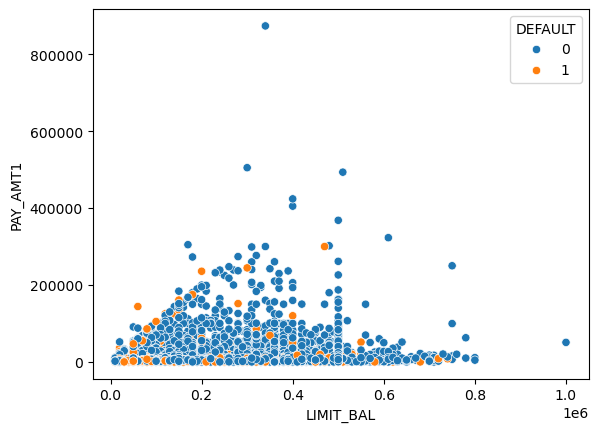

In [40]:
sns.scatterplot(
    x="LIMIT_BAL",
    y="PAY_AMT1",
    hue="DEFAULT",
    data=df
)

plt.show()
# Interpretation: Assess whether customers with higher credit limits make larger payments.

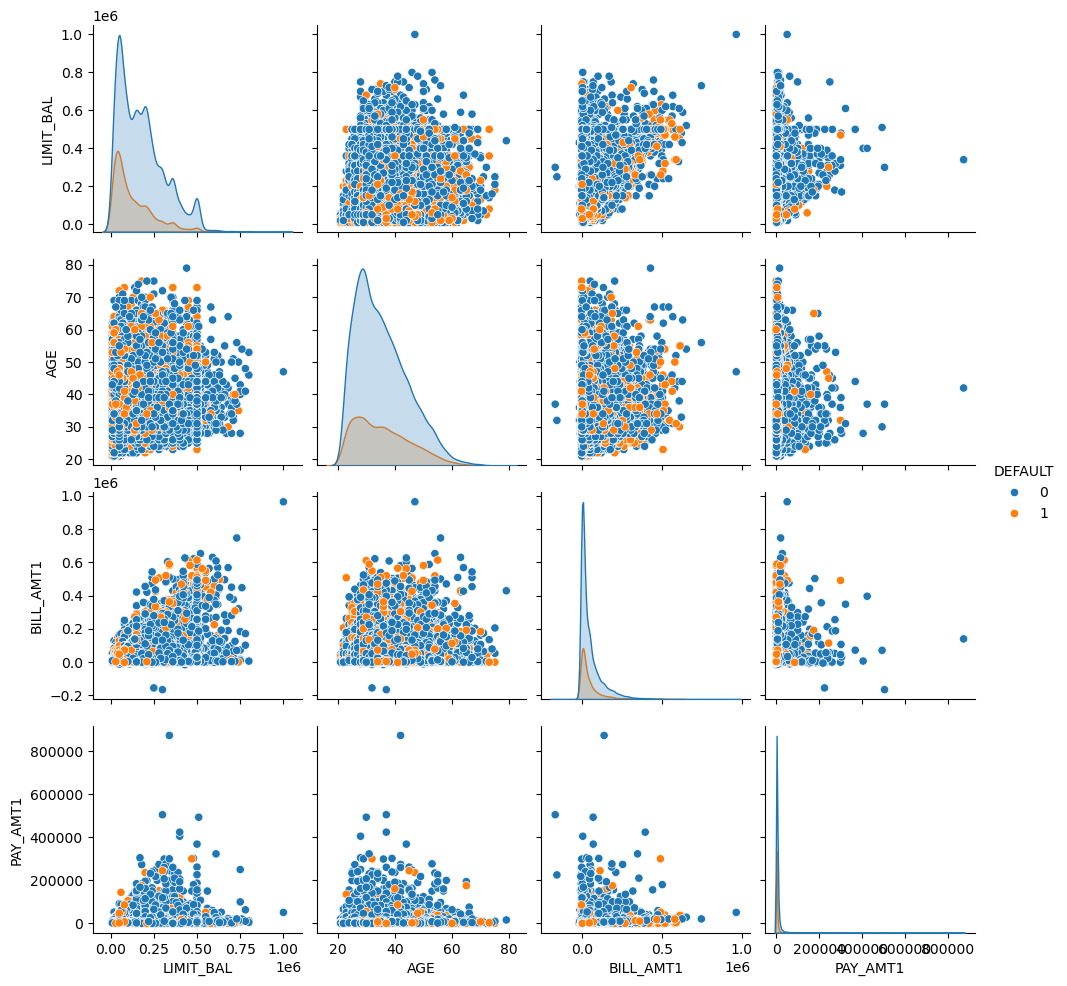

In [41]:
cols = ["LIMIT_BAL","AGE","BILL_AMT1","PAY_AMT1","DEFAULT"]

sns.pairplot(
    df[cols],
    hue="DEFAULT"
)


plt.show()

In [42]:
df.groupby("SEX")["DEFAULT"].mean()*100

SEX
1    24.167227
2    20.776281
Name: DEFAULT, dtype: float64

In [43]:
df.groupby("MARRIAGE")["DEFAULT"].mean()*100

MARRIAGE
1    23.471704
2    20.928339
3    23.607427
Name: DEFAULT, dtype: float64

In [44]:
df.groupby("EDUCATION")["DEFAULT"].mean()*100

EDUCATION
1    19.234766
2    23.734854
3    25.157616
4     7.051282
Name: DEFAULT, dtype: float64

### Feature Engineering

In [45]:
# Adding all the total bill for each customers together and creating a column in the table df

df["TOTAL_BILL"] = (
    df["BILL_AMT1"] +
    df["BILL_AMT2"] +
    df["BILL_AMT3"] +
    df["BILL_AMT4"] +
    df["BILL_AMT5"] +
    df["BILL_AMT6"]
)

df["TOTAL_BILL"]

0          7704
1         17077
2        101653
3        231334
4        109339
          ...  
29995    725349
29996     21182
29997     70496
29998    266611
29999    230874
Name: TOTAL_BILL, Length: 30000, dtype: int64

In [46]:
# Adding all the total bill for each customers together and creating a column in the table df
df["TOTAL_PAYMENT"] = (
    df["PAY_AMT1"] +
    df["PAY_AMT2"] +
    df["PAY_AMT3"] +
    df["PAY_AMT4"] +
    df["PAY_AMT5"] +
    df["PAY_AMT6"]
)

df["TOTAL_PAYMENT"]

0           689
1          5000
2         11018
3          8388
4         59049
          ...  
29995     42550
29996     14490
29997     31300
29998    147181
29999      8308
Name: TOTAL_PAYMENT, Length: 30000, dtype: int64

In [47]:
# Subtracting total payment from total bill for each customer to show the tendency of being defaulting

df["INDICATOR"] = df["TOTAL_BILL"] - df["TOTAL_PAYMENT"]

df["INDICATOR"]

0          7015
1         12077
2         90635
3        222946
4         50290
          ...  
29995    682799
29996      6692
29997     39196
29998    119430
29999    222566
Name: INDICATOR, Length: 30000, dtype: int64

In [48]:
# Creating a function to categorize the difference

def indicator (row):
    if row < 0:
        return 1
    else:
        return 0

In [49]:
# Creating a column and applying the function

df["DEFAULT_PAYMENTS"] = df["INDICATOR"].apply(indicator)

In [50]:
# Confirming the addition

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,TOTAL_BILL,TOTAL_PAYMENT,INDICATOR,DEFAULT_PAYMENTS
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,7704,689,7015,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,17077,5000,12077,0
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,101653,11018,90635,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,231334,8388,222946,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,109339,59049,50290,0


In [51]:
# Categorizing to know the customer with negative default payment

df["DEFAULT_PAYMENTS"].value_counts()

DEFAULT_PAYMENTS
0    26798
1     3202
Name: count, dtype: int64

The above output shows that the number of defaulters are far less than the number of the customer that will not default. Again, Inbalance data.

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df.drop(["DEFAULT", "TOTAL_BILL", "TOTAL_PAYMENT", "INDICATOR", "DEFAULT_PAYMENTS"], axis=1)
)

X_scaled

array([[-1.13672015,  0.81016074,  0.21186989, ..., -0.30806256,
        -0.31413612, -0.29338206],
       [-0.3659805 ,  0.81016074,  0.21186989, ..., -0.24422965,
        -0.31413612, -0.18087821],
       [-0.59720239,  0.81016074,  0.21186989, ..., -0.24422965,
        -0.24868274, -0.01212243],
       ...,
       [-1.05964618, -1.23432296,  0.21186989, ..., -0.03996431,
        -0.18322937, -0.11900109],
       [-0.67427636, -1.23432296,  1.55508562, ..., -0.18512036,
         3.15253642, -0.19190359],
       [-0.90549825, -1.23432296,  0.21186989, ..., -0.24422965,
        -0.24868274, -0.23713013]], shape=(30000, 23))

In [53]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,2,1,1,0,3,4,4,1,1,0,0,2710,2306,846,377,384,414,0,494,0,0,0,0
1,12,1,1,1,5,1,4,2,2,2,3,2064,1547,2053,2344,2452,2402,0,699,885,946,0,1797
2,9,1,1,1,13,2,2,2,2,2,2,10068,6073,5886,6135,6365,6480,1211,1185,885,946,949,3576
3,5,1,1,0,16,2,2,2,2,2,2,12731,12968,13353,10118,10391,10482,1674,1674,1079,1043,1018,928
4,5,0,1,0,36,1,2,1,2,2,2,4628,3418,11227,8476,7794,7708,1674,7301,5346,4841,647,630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,22,0,2,0,18,2,2,2,2,2,2,20978,20815,20904,16933,11087,6601,5201,6732,3737,2574,3576,928
29996,15,0,2,1,22,1,1,1,1,2,2,1476,1606,2452,4475,3143,414,1520,2854,5125,117,0,0
29997,3,0,1,1,16,6,5,4,1,2,2,2533,2430,2086,8460,8473,7828,0,0,6573,3249,1795,2582
29998,8,0,2,0,20,3,1,2,2,2,1,56,16306,16101,14106,5519,13293,7762,2775,1058,1771,6552,1638


In [54]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
)


print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (24000, 23)
Testing samples: (6000, 23)


In [55]:
log = LogisticRegression()

log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
log_preds = log.predict(X_test)

In [57]:
#accuracy ranges from 0 to 1
accuracy_score(y_test, log_preds)

0.8098333333333333

In [58]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [59]:
cm = confusion_matrix(y_test, log_preds)

cm

array([[4550,  137],
       [1004,  309]])

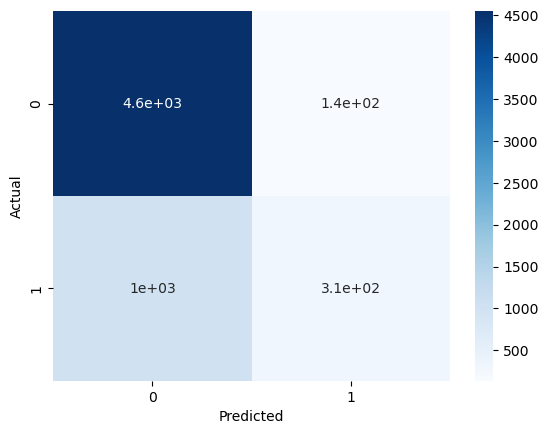

In [60]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [70]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
# Model 3: Random Forest (Recommended)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [72]:
# Logistic Regression Evaluation
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))
# Decision Tree Evaluation
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))
# Random Forest Evaluation
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Logistic Regression
Accuracy: 0.8098333333333333
Precision: 0.6928251121076233
Recall: 0.23533891850723535
F1 Score: 0.35133598635588403
ROC AUC: 0.6030545669984438

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

Decision Tree
Accuracy: 0.7233333333333334
Precision: 0.3790940766550523
Recall: 0.4143183549124143
F1 Score: 0.39592430858806404
ROC AUC: 0.6121090387747478

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4687
           1       0.38      0.41      0.40      1313

    accuracy                           0.72      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.7

In [73]:
results = { 
    "Model":["Logistic Regression","Decision Tree","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ]
}

In [74]:
pd.DataFrame(results)
# This table makes it easy to compare the performance of all three models.

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809833,0.692825,0.235339,0.351336
1,Decision Tree,0.723333,0.379094,0.414318,0.395924
2,Random Forest,0.817500,0.642670,0.373953,0.472797


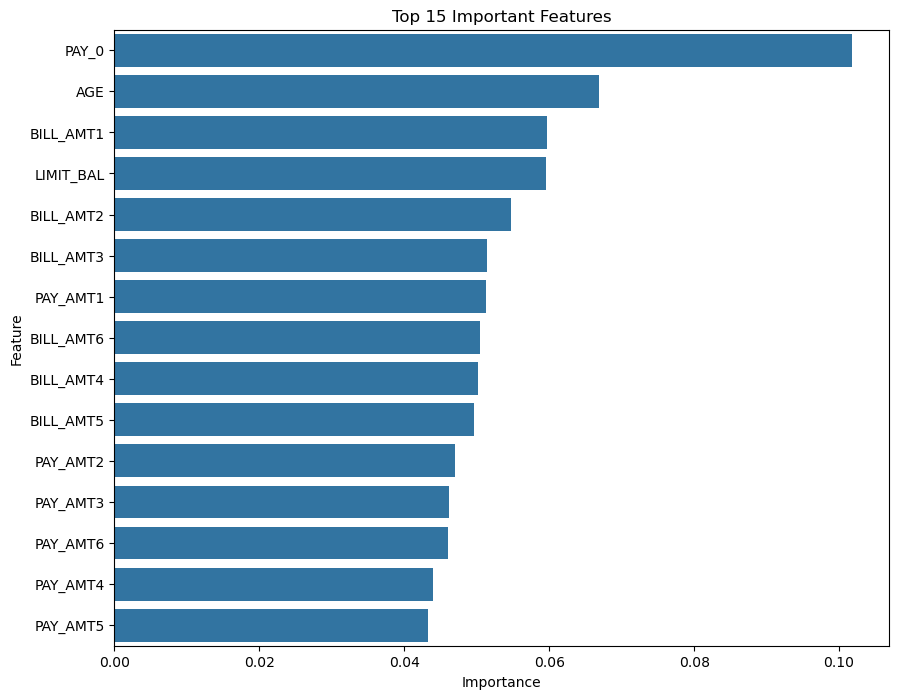

In [76]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)
# Plot Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Improved Credit Card Default Prediction

## Executive-ready modelling section

This section continues the original analysis and strengthens the modelling workflow. The focus is on identifying customers likely to default, while avoiding data leakage and giving greater importance to Recall, F1 Score, ROC-AUC and PR-AUC because the default class is smaller than the non-default class.

**Important:** The original notebook scaled the full dataset before the train/test split. In this revised section, scaling is performed inside a Pipeline so that the scaler is fitted only on training data. Random Forest is not scaled because tree-based models do not require feature scaling.


In [ ]:
# Additional imports for the improved modelling workflow

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 1. Prepare the modelling data

The engineered financial columns are excluded from the predictor matrix in the same way as the original notebook. The target variable is `DEFAULT`.


In [ ]:
# Define features and target

feature_columns = [
    col for col in df.columns
    if col not in [
        "DEFAULT",
        "TOTAL_BILL",
        "TOTAL_PAYMENT",
        "INDICATOR",
        "DEFAULT_PAYMENTS"
    ]
]

X_model = df[feature_columns].copy()
y_model = df["DEFAULT"].astype(int).copy()

print("Feature shape:", X_model.shape)
print("Target shape:", y_model.shape)

print("\nTarget distribution:")
print(y_model.value_counts())

print("\nTarget percentage:")
print((y_model.value_counts(normalize=True) * 100).round(2))


### Business interpretation

The target distribution shows that non-defaulters are more numerous than defaulters. This means a model can achieve high accuracy simply by favouring the majority class. For credit-risk management, missing actual defaulters can be costly, so the improved analysis will pay particular attention to Recall, Precision and F1 Score.


In [ ]:
# Stratified train-test split
# Stratification keeps approximately the same default proportion in both sets.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("Training rows:", X_train_raw.shape[0])
print("Testing rows:", X_test_raw.shape[0])

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))


## 2. Balanced Logistic Regression

`class_weight="balanced"` gives additional weight to the minority class. This encourages the model to pay more attention to potential defaulters. Scaling is placed inside the Pipeline to prevent data leakage.


In [ ]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_pipeline.fit(X_train_raw, y_train)

y_pred_lr_balanced = logistic_pipeline.predict(X_test_raw)
y_prob_lr_balanced = logistic_pipeline.predict_proba(X_test_raw)[:, 1]


In [ ]:
print("Balanced Logistic Regression")
print("=" * 35)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr_balanced), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr_balanced, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr_balanced, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr_balanced, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr_balanced), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_lr_balanced), 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr_balanced, zero_division=0))


## 3. Balanced Random Forest

Random Forest was the strongest of the original three models in the notebook. We now rebalance it and increase the number of trees to improve stability.


In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train_raw, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test_raw)
y_prob_rf_balanced = rf_balanced.predict_proba(X_test_raw)[:, 1]


In [ ]:
print("Balanced Random Forest")
print("=" * 30)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf_balanced), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf_balanced, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf_balanced, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf_balanced, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf_balanced), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_rf_balanced), 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf_balanced, zero_division=0))


## 4. Five-fold cross-validation

Cross-validation checks whether the Random Forest performs consistently across different portions of the dataset instead of relying on one train/test split.


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    rf_balanced,
    X_model,
    y_model,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Mean Score": [cv_results[f"test_{m}"].mean() for m in scoring],
    "Std Dev": [cv_results[f"test_{m}"].std() for m in scoring]
})

cv_summary.round(4)


## 5. Hyperparameter tuning

The next step searches for a stronger Random Forest configuration. F1 Score is used as the main optimisation metric because it balances Precision and Recall. RandomizedSearchCV is used instead of a very large grid to keep the notebook practical.


In [ ]:
from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(200, 501),
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_raw, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation F1 Score:")
print(round(random_search.best_score_, 4))


In [ ]:
# Evaluate the tuned Random Forest on the untouched test set

best_rf = random_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_raw)
y_prob_best_rf = best_rf.predict_proba(X_test_raw)[:, 1]

print("Tuned Random Forest")
print("=" * 25)
print("Accuracy:", round(accuracy_score(y_test, y_pred_best_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_best_rf, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_best_rf, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_best_rf, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_best_rf), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_best_rf), 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best_rf, zero_division=0))


## 6. Confusion Matrix

The confusion matrix shows how many customers were correctly or incorrectly classified. For the bank, the most important error to monitor is a **false negative**: a customer who actually defaults but is predicted as a non-defaulter.


In [ ]:
cm = confusion_matrix(y_test, y_pred_best_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot()

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


## 7. ROC and Precision-Recall curves

ROC-AUC measures the model's ability to distinguish between the two classes across thresholds. PR-AUC is especially useful when the positive class is less common.


In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best_rf,
    name="Tuned Random Forest"
)
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_best_rf,
    name="Tuned Random Forest"
)
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.show()


## 8. Prediction-threshold analysis

The standard classification threshold is 0.50. However, a bank may prefer a lower threshold if it wants to identify more potentially risky customers. The table below tests several thresholds and compares Precision, Recall and F1 Score.


In [ ]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_best_rf >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)


In [ ]:
best_threshold_row = threshold_df.loc[threshold_df["F1 Score"].idxmax()]

print("Best threshold based on F1 Score:")
print(best_threshold_row.round(4))


## 9. Feature importance

This section identifies the variables the tuned Random Forest relied on most heavily when making predictions. Feature importance indicates predictive usefulness; it does **not** prove that a variable causes default.


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(20)


In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Default Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 10. Final model comparison

This table compares the original models from the notebook with the improved balanced and tuned approaches. The final model should not be selected on accuracy alone.


In [ ]:
# Probabilities for the original models
# These variables already exist from the original notebook.

original_lr_prob = lr.predict_proba(X_test)[:, 1]
original_dt_prob = dt.predict_proba(X_test)[:, 1]
original_rf_prob = rf.predict_proba(X_test)[:, 1]

final_results = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Original Decision Tree",
        "Original Random Forest",
        "Balanced Logistic Regression",
        "Balanced Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr_balanced),
        accuracy_score(y_test, y_pred_rf_balanced),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_lr_balanced, zero_division=0),
        precision_score(y_test, y_pred_rf_balanced, zero_division=0),
        precision_score(y_test, y_pred_best_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_lr_balanced, zero_division=0),
        recall_score(y_test, y_pred_rf_balanced, zero_division=0),
        recall_score(y_test, y_pred_best_rf, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_lr_balanced, zero_division=0),
        f1_score(y_test, y_pred_rf_balanced, zero_division=0),
        f1_score(y_test, y_pred_best_rf, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, original_lr_prob),
        roc_auc_score(y_test, original_dt_prob),
        roc_auc_score(y_test, original_rf_prob),
        roc_auc_score(y_test, y_prob_lr_balanced),
        roc_auc_score(y_test, y_prob_rf_balanced),
        roc_auc_score(y_test, y_prob_best_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, original_lr_prob),
        average_precision_score(y_test, original_dt_prob),
        average_precision_score(y_test, original_rf_prob),
        average_precision_score(y_test, y_prob_lr_balanced),
        average_precision_score(y_test, y_prob_rf_balanced),
        average_precision_score(y_test, y_prob_best_rf)
    ]
})

final_results.sort_values("F1 Score", ascending=False).round(4)


## Executive conclusion

The original analysis established that Random Forest was the strongest of the three initial models. The improved workflow now addresses the main limitations of the original modelling approach: class imbalance, potential scaling leakage, sensitivity to one train/test split, and reliance on accuracy alone.

The tuned model should be judged primarily by its ability to identify actual defaulters while maintaining an acceptable level of false alarms. In a real banking environment, the final probability threshold should be selected using the financial cost of false negatives and false positives, followed by validation on new external data.

**Business objective:** use the model as a decision-support tool to identify higher-risk customers early, enabling appropriate credit monitoring and intervention rather than relying on automated rejection alone.
